In [1]:
from itertools import chain
import anndata as ad
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import scanpy.external as sce
import seaborn as sns
import glasbey

import warnings
warnings.filterwarnings("ignore")

sc.logging.print_header()

Package,Version
anndata,0.12.7
matplotlib,3.10.8
numpy,2.3.5
pandas,2.3.3
scanpy,1.11.5
seaborn,0.13.2
glasbey,0.3.0
Component,Info
Python,"3.11.5 (main, Sep 11 2023, 13:54:46) [GCC 11.2.0]"
OS,Linux-4.18.0-553.141.2.el8_10.x86_64-x86_64-with-glibc2.28


In [2]:
# Load the preprocessed thymus dataset
adata = sc.read('/cluster/pixstor/warrenwc-lab/users/rachel/single-cell/251217-chickenRBCs/3-cluster/clusters_original.h5ad')

In [3]:
%matplotlib inline
matplotlib.rcParams["figure.figsize"] = (9.0, 9.0)

In [4]:
aggregation = pd.read_csv("/cluster/pixstor/warrenwc-lab/users/rachel/single-cell/251217-chickenRBCs/samples.csv")
aggregation

,sample_id,population
0,C1_GEX,adult
1,C3_GEX,adult
2,C4_GEX,adult
3,E2_GEX,embryo
4,E3_GEX,embryo
5,E4_GEX,embryo


In [5]:
print("Original number of cells per sample:")
print(adata.obs.groupby("sample_id").size())

Original number of cells per sample:
sample_id
C1_GEX    6327
C3_GEX    4665
C4_GEX    3824
E2_GEX    6213
E3_GEX    6678
E4_GEX    9901
dtype: int64


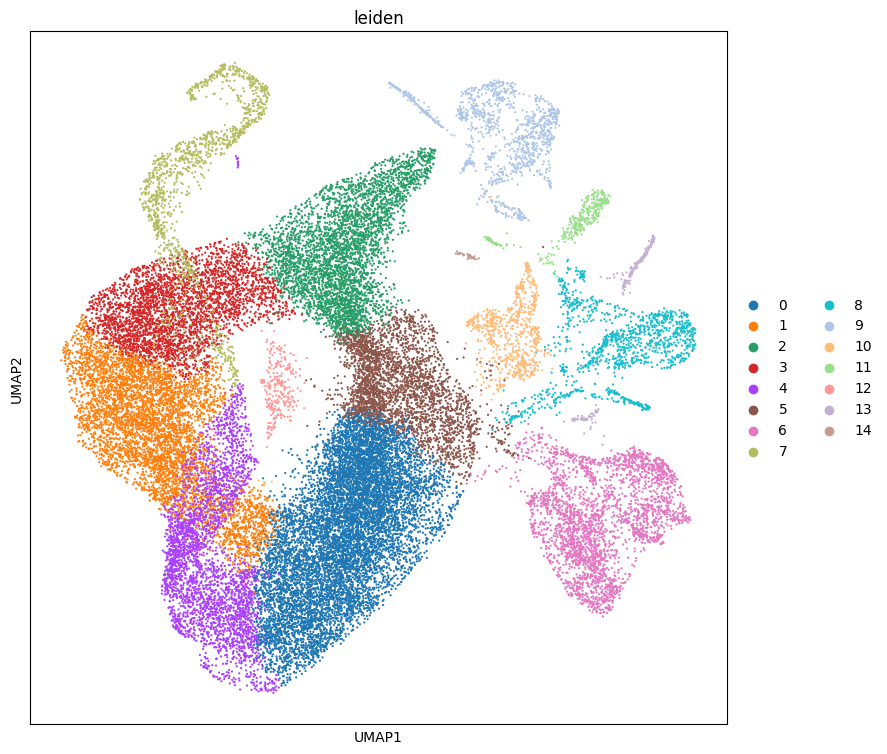

In [6]:
sc.pl.umap(adata, color=["leiden"], s=10)

In [7]:
adata.obs['leiden'][adata.obs['leiden'].isin(['1', '2', '3', '4', '5', '7', '12', '14'])]='0'
adata.obs['leiden']=adata.obs['leiden'].astype('str').astype('category')

In [8]:
old_to_new = {
    '0':'Erythrocytes',
    '9':'Leukocytes',
    '11':'T-cells',
    '6':'Fibroblasts',
    '8':'Vascular',
    '13':'Thrombocytes',
    '10':'Epithelial',
}
adata.obs['cell type'] = (
    adata.obs['leiden']
    .map(old_to_new)
    .astype('category')
)

In [9]:
adata.obs['cell type'].value_counts(),

(cell type
 Erythrocytes    30926
 Fibroblasts      2878
 Vascular         1262
 Leukocytes       1200
 Epithelial        757
 T-cells           340
 Thrombocytes      245
 Name: count, dtype: int64,)

In [10]:
glasbey.create_palette(palette_size=7, lightness_bounds=(30, 60), chroma_bounds=(40, 60), hue_bounds=(-90.0, 90.0))

['#b25108', '#fb71a2', '#caa200', '#a22d5d', '#f7824d', '#755d00', '#be6165']

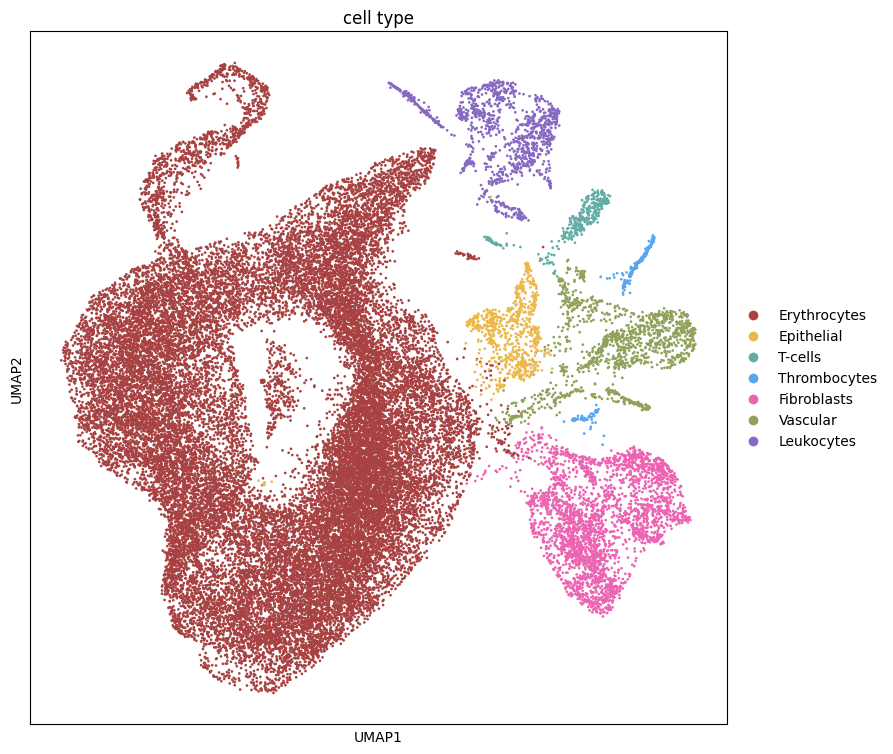

In [11]:
sc.pl.umap(adata, 
           color=["cell type"],
           palette={"Erythrocytes": "#A84242", 
                   "T-cells": "#61ADA5", 
                   "Thrombocytes": "#59A5F0", 
                   "Epithelial": "#EBB84B", 
                   "Fibroblasts": "#EB63B1", 
                   "Vascular": "#90A15A", 
                   "Leukocytes": "#8669c2"},
          s=15,
          save="_cell_type")

In [12]:
adata.write("total_lung_cell_type.h5ad")

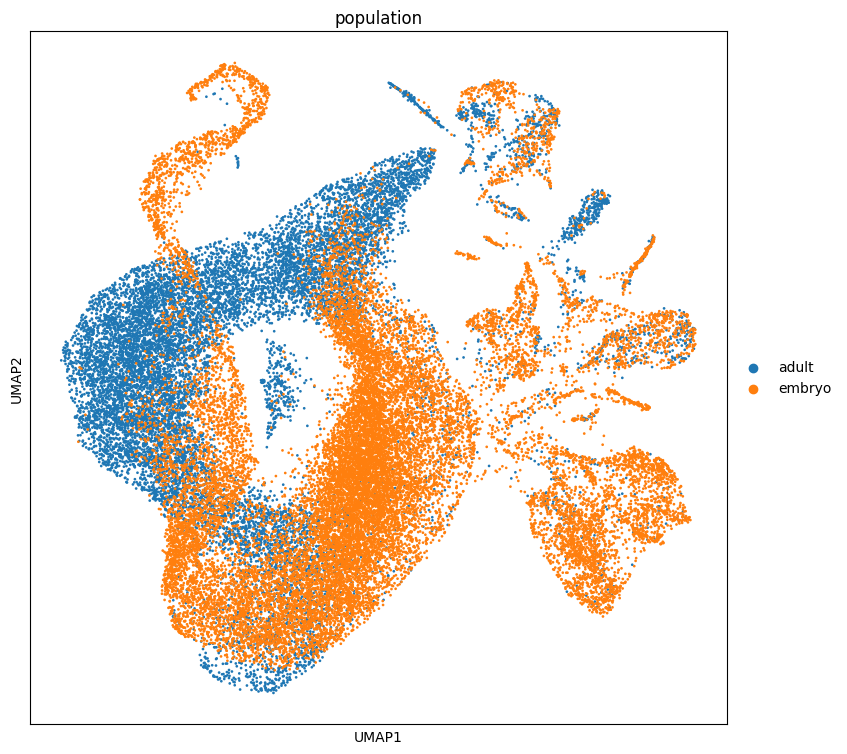

In [13]:
sc.pl.umap(adata, 
           color=["population"], 
           s=15, 
           save="_by_pop")

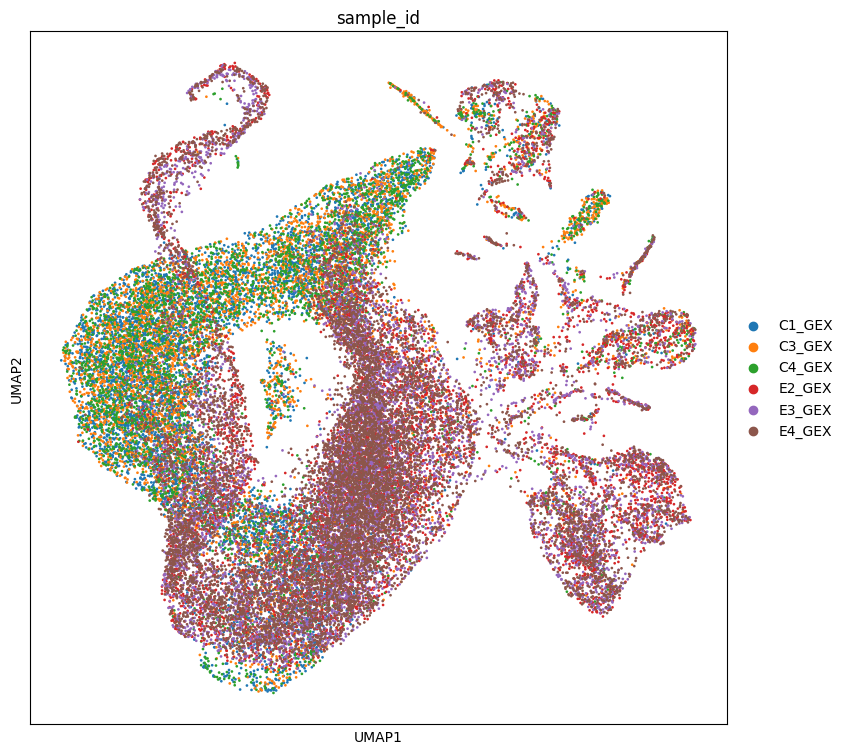

In [14]:
sc.pl.umap(adata, 
           color=["sample_id"],
           s=15)

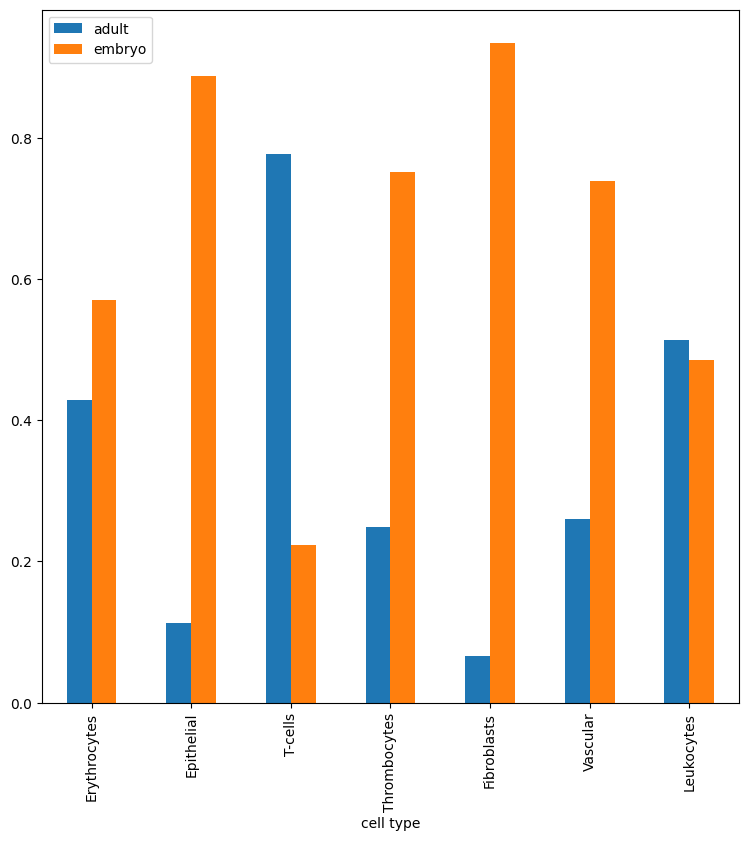

In [15]:
tmp = pd.crosstab(adata.obs['cell type'],adata.obs['population'], normalize='index')
tmp.plot.bar(stacked=False).legend(loc='upper left')

In [16]:
colors = [(0.9, 0.9, 0.9), (0.7, 0, 0)]
cm = matplotlib.colors.LinearSegmentedColormap.from_list(
        "Custom", colors, N=40)
sc.set_figure_params(frameon=False, transparent=True)
matplotlib.rcParams["figure.figsize"] = (9.0, 9.0)
matplotlib.rcParams["font.size"] = 18

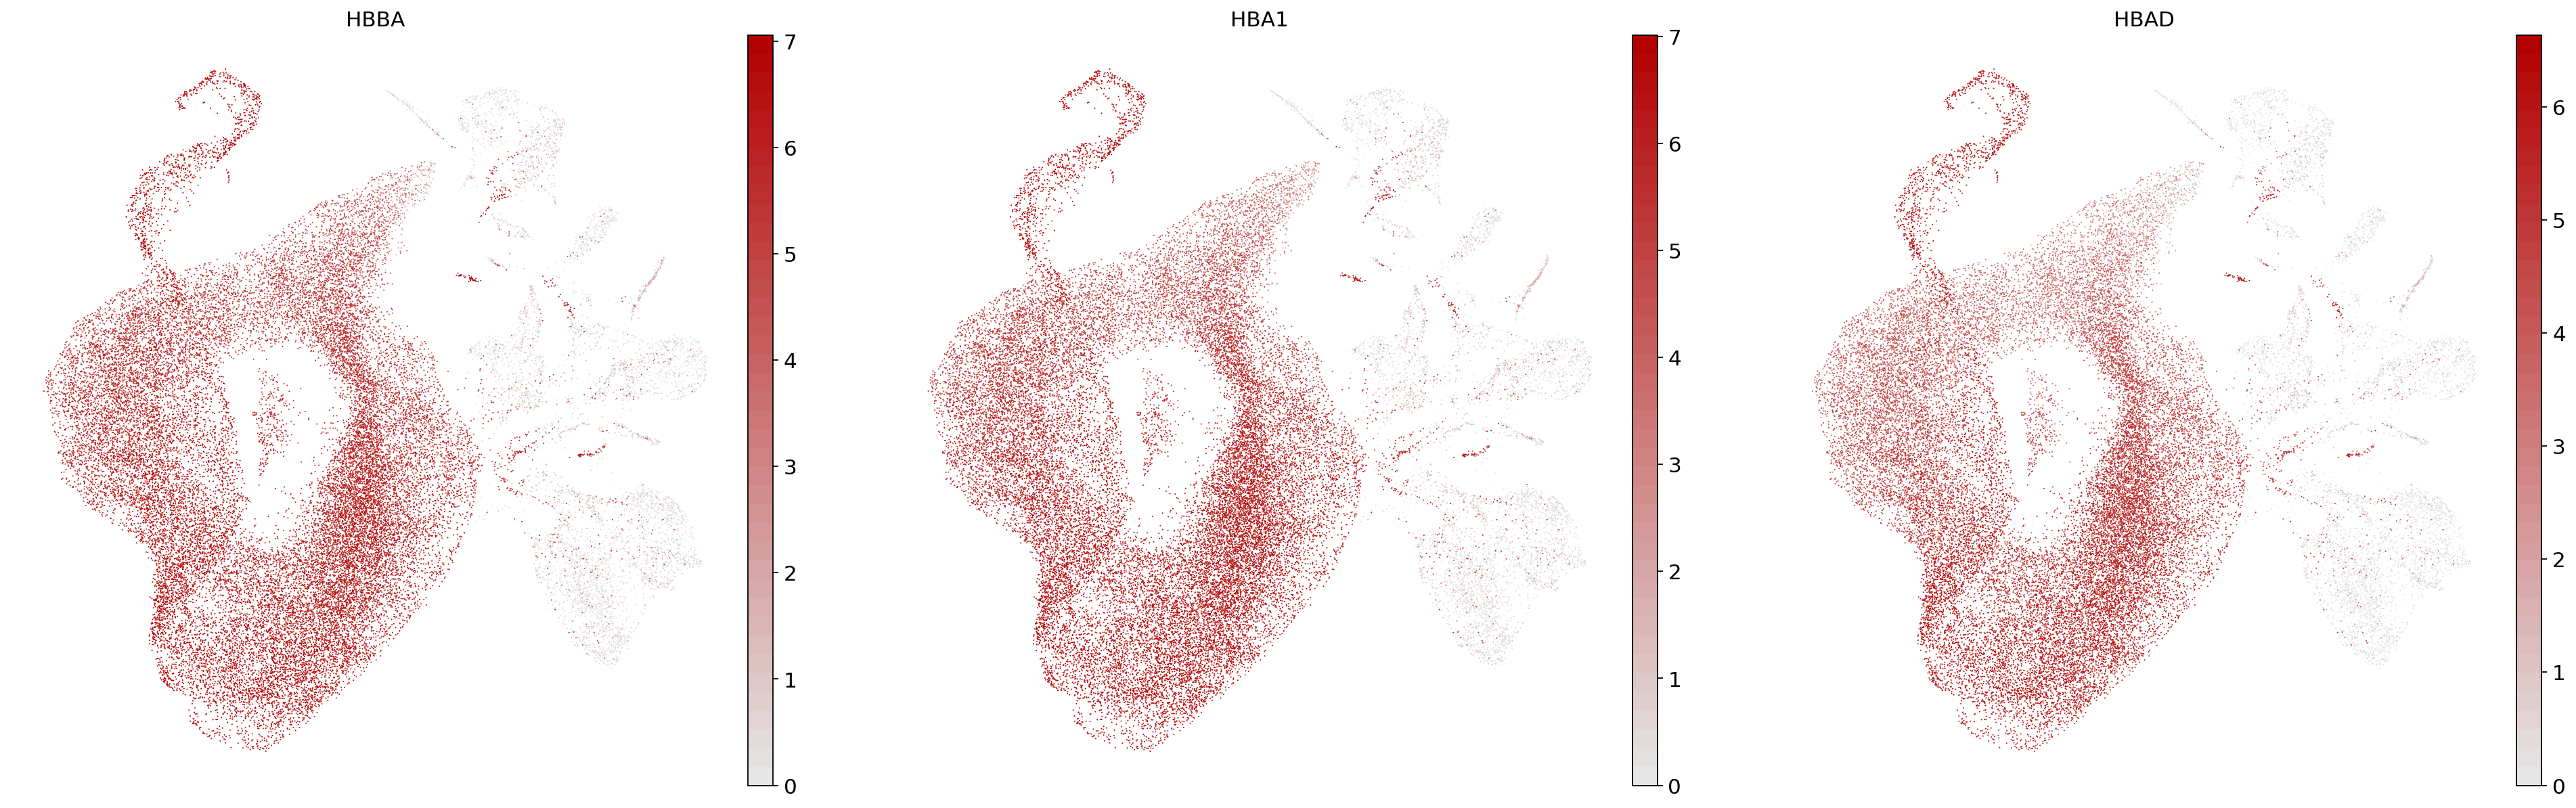

In [17]:
rbc_genes = [
    "HBBA", "HBA1", "HBAD"
]
sc.pl.umap(
    adata,
    color=rbc_genes,
    color_map=cm,
    save="_rbc_genes.pdf",
    #title=t_cell_genes.symbol,
)

In [18]:
# Ensure you are using the t_cell_clusters dataset after reclustering
# Check unique clusters to confirm
print("Unique cluster", adata.obs['cell type'].unique())

# Step 1: Rank genes based on clustering results for T cell clusters
sc.tl.rank_genes_groups(adata, groupby='cell type', method='t-test')

# Step 2: Extract the marker genes table
marker_genes_table = pd.DataFrame(adata.uns["rank_genes_groups"]["names"]).head(40).T

marker_genes_table.to_csv("total_lung_marker_genes.csv")

# Display the marker genes table
marker_genes_table

Unique cluster ['Erythrocytes', 'Thrombocytes', 'Vascular', 'T-cells', 'Leukocytes', 'Fibroblasts', 'Epithelial']
Categories (7, object): ['Erythrocytes', 'Epithelial', 'T-cells', 'Thrombocytes', 'Fibroblasts', 'Vascular', 'Leukocytes']


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
Erythrocytes,HBBA,HBA1,HBAD,WBP4,CA2,CA13,ENSGALG00000022875,IFI27L2,ENSGALG00000031149,AK2,...,RFESD,ENSGALG00000034591,TFRC,RBIS,PON1,NDUFB6,TRIM27.1,MAIP1,LAMTOR5,KIAA0232
Epithelial,ENSGALG00000050132,COX3,ENSGALG00000042748,MT-CO1,CST3,COII,ATP6,CYTB,ND5,SYNE2,...,MT4,NPM1,AFDN,TMSB4X,AQP1,ND4L,NME2,ESRP2,KTN1,ENSGALG00000043329
T-cells,TMSB4X,MYH9,CORO1C,ACTB,PPIA,RAC2,CD3D,PTPRC,ACTG1,ENSGALG00000050132,...,CD44,RPL27A,RPL36,TPM3,MSN,RPS14,ANKRD44,LCP2,ETS1,SYNE1
Thrombocytes,TMSB4X,CSTA,IFI6,TPM2,ENSGALG00000046729,RGS18,COII,PMP22,RAC2,COX3,...,ITGB1,TIMP3,IFI30,PDE4D,TAGLN2,VAV3,CYTB,ITGAV,KCNMA1,PDLIM1
Fibroblasts,SPARC,COL6A3,DCN,COL5A1,COL6A2,ENSGALG00000050132,COL3A1,FN1,COX3,MMP2,...,ND5,SPTBN1,CD81,MYH10,SERPINH1,COL4A1,SLIT3,NCAM1,LAMA4,OGN
Vascular,TMSB4X,ENSGALG00000043329,PPIA,ENSGALG00000050132,MT-CO1,ACTB,COII,CYTB,COX3,ACTG1,...,TPM2,ANXA6,NPM1,GNAI2,CDH5,IGFBP7,ENSGALG00000007646,PECAM1,SEPT7,SDC2
Leukocytes,TMSB4X,ACTB,IFI30,CD74,ENSGALG00000050132,ACTG1,BLB2,DSTN,PPIA,CORO1C,...,ENO1,MYH9,LTA4H,MYL6,COTL1,ATP6,SPI1,CALM1,RHOA,ENSGALG00000033530


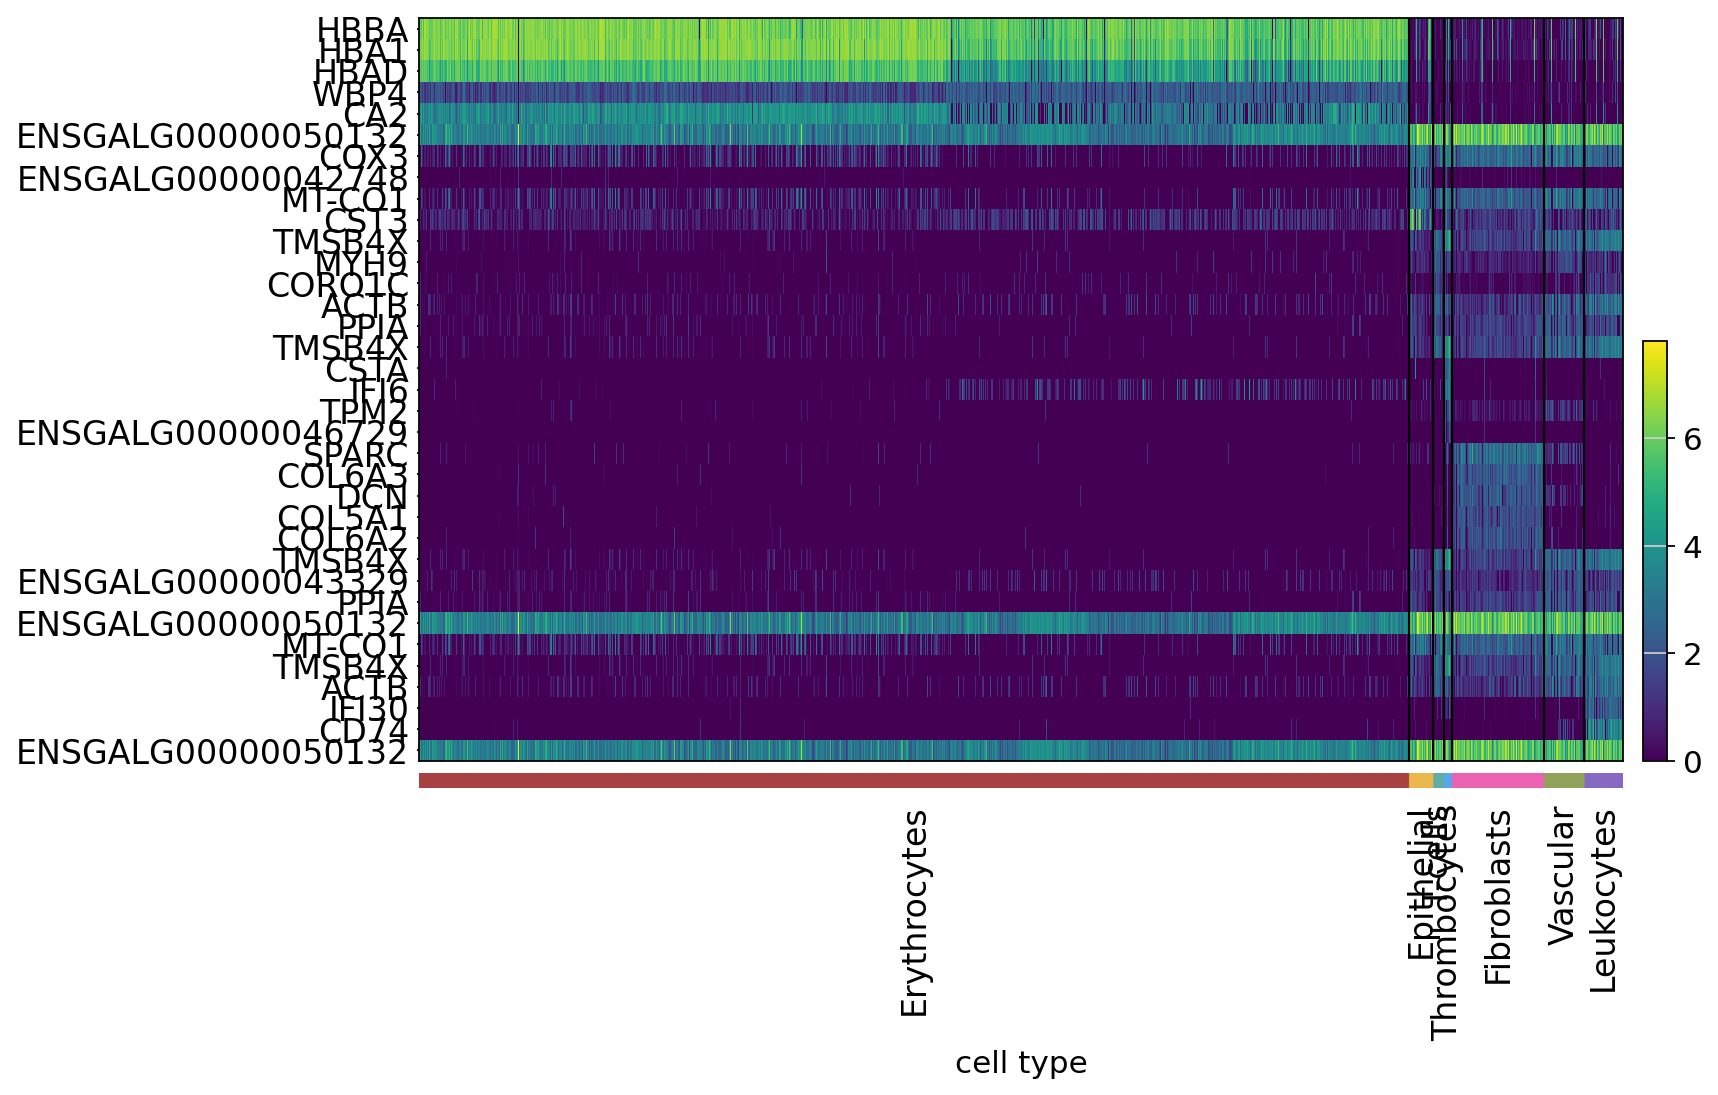

In [19]:
marker_genes_list = list(chain(*marker_genes_table.iloc[:,:5].values))
sc.pl.heatmap(
    adata,
    var_names=marker_genes_list,
    groupby="cell type",
    swap_axes=True,
    show_gene_labels=True,
    save="total_lung_top5markers.pdf"
)

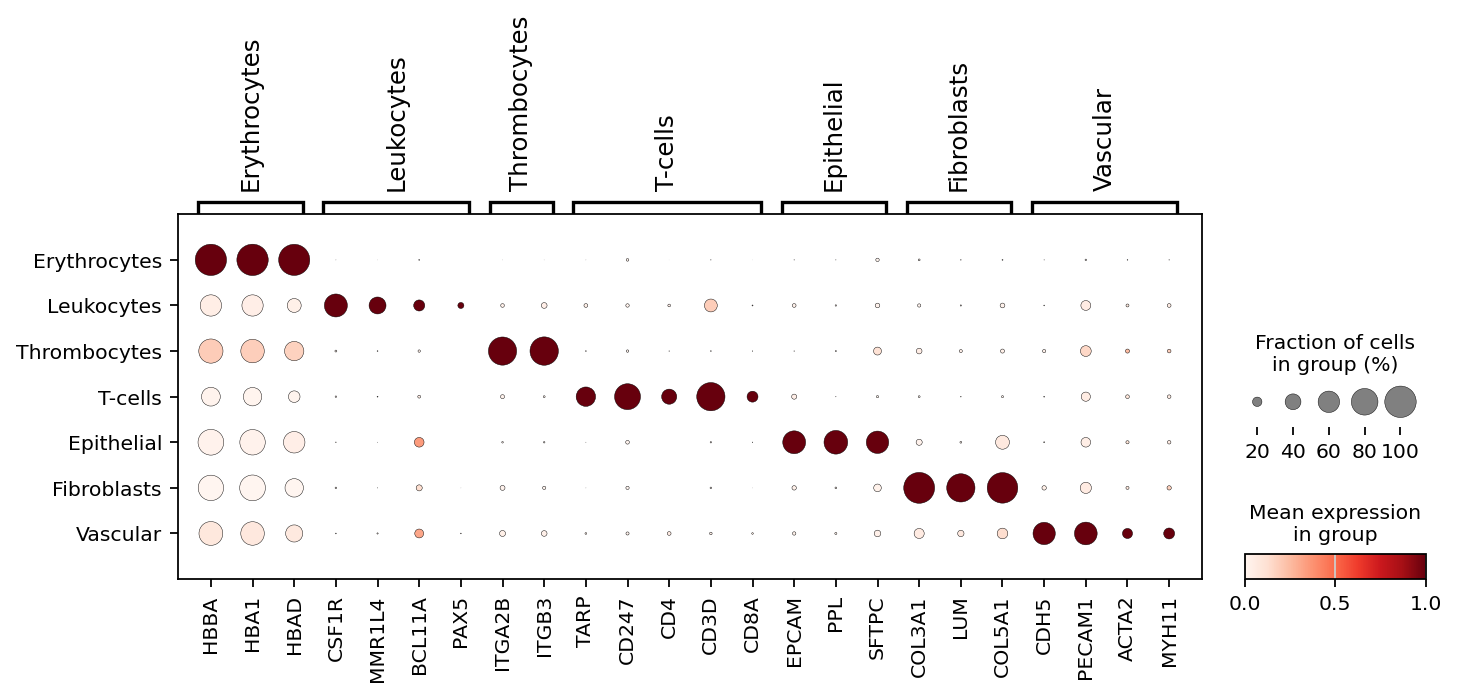

<module 'scanpy.plotting' from '/home/emvrn/.local/lib/python3.11/site-packages/scanpy/plotting/__init__.py'>

In [20]:
# Define the custom order for clusters (descending) on the Y-axis
cluster_order = ["Erythrocytes", "Leukocytes", "Thrombocytes", "T-cells", "Epithelial", "Fibroblasts", "Vascular"]
cluster_order = [str(c) for c in cluster_order]  # Ensure leiden values are strings

# Your existing marker genes dictionary
marker_genes = {
    "Erythrocytes": ["HBBA", "HBA1", "HBAD"],
    "Leukocytes": ["CSF1R", "MMR1L4", "BCL11A", "PAX5"],
    "Thrombocytes": ["ITGA2B", "ITGB3"],
    "T-cells": ["TARP", "CD247", "CD4", "CD3D", "CD8A"],
    "Epithelial":["EPCAM", "PPL", "SFTPC"],
    "Fibroblasts":["COL3A1", "LUM", "COL5A1"],
    "Vascular":["CDH5", "PECAM1", "ACTA2", "MYH11"],
}

# Ensure leiden is categorical and set the correct order
adata.obs["cell type"] = adata.obs["cell type"].astype("category")
adata.obs["cell type"] = adata.obs["cell type"].cat.reorder_categories(cluster_order, ordered=True)

# Adjust font size for labels
plt.rcParams['font.size'] = 11

# Create the dot plot with clusters on the Y-axis in descending order
sc.pl.dotplot(
    adata, marker_genes, 
    groupby="cell type", 
    standard_scale="var",
    cmap = 'Reds',
    swap_axes=False,  # Keep clusters on Y-axis (default)
    figsize=(10, 3),
    save="FINAL-dotplot.pdf"
)

sc.pl